Market stats, non nones count: 774, needs 774
              AAPL      MSFT  GBPUSD=X
20250214  0.012630 -0.005153  0.009017
20250217  0.000000  0.000000  0.001647
20250218 -0.000532  0.002958  0.002962
20250219  0.001635  0.012445  0.000341
20250220  0.003913  0.005277 -0.003303
...            ...       ...       ...
20260209 -0.011729  0.030589  0.006497
20260210 -0.003429 -0.000798  0.005459
20260211  0.006628 -0.021771 -0.003579
20260212 -0.051274 -0.006276 -0.000775
20260213 -0.011181  0.004853  0.001812

[258 rows x 3 columns]


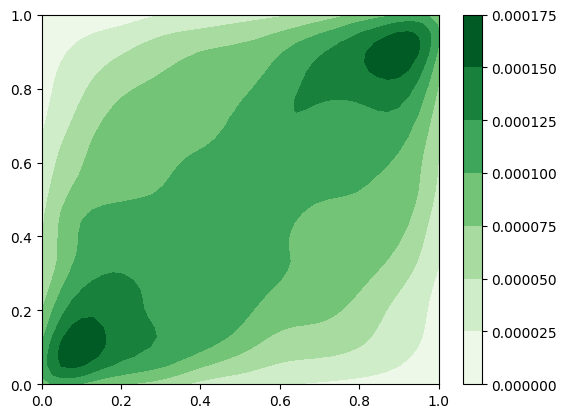

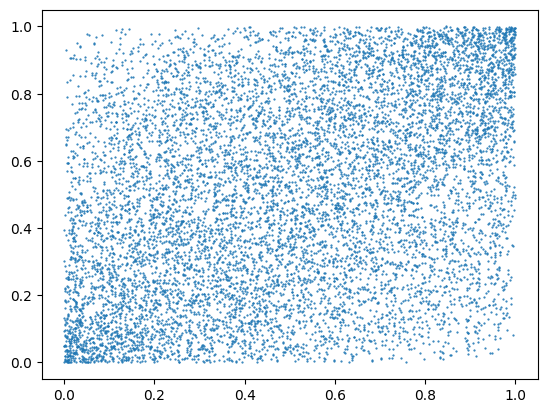

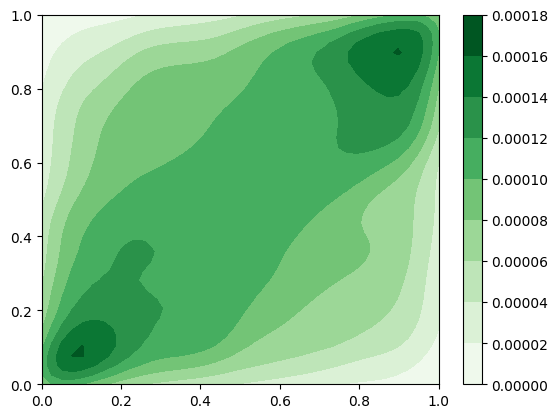

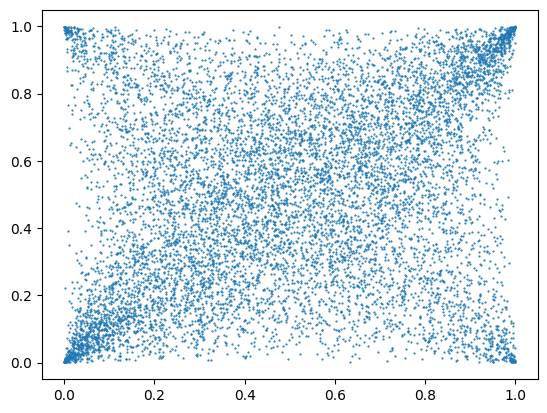

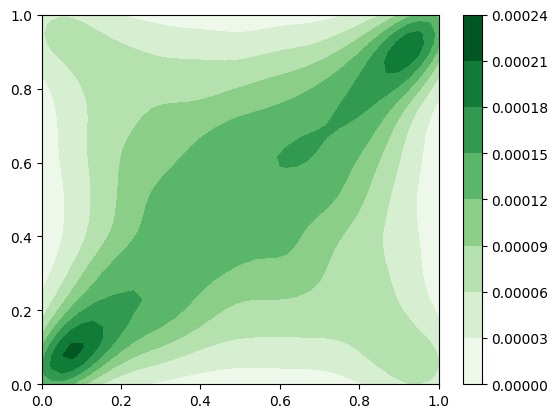

In [3]:
import market as mkt
import jointsim as js


data, spot = mkt.get_market(ticker_list=['AAPL', 'MSFT', 'GBPUSD=X'], period='1y', interval='1d')
print(data)

rf_dir = [1.0, 1.0, -1.0]
copula = js.GaussCopulaCorr(data, rf_dir)
copula.get_sims(10000)
copula.plot_contour(0, 1)

rf_dir = [1.0, 1.0, -1.0]
copula = js.GaussCopulaNum(data, rf_dir)
copula.get_sims(10000)
copula.plot_sims(0, 1)
copula.plot_contour(0, 1)

rf_dir = [1.0, 1.0, -1.0]
copula = js.CauchyCopulaNum(data, rf_dir)
copula.get_sims(10000)
copula.plot_sims(0, 1)
copula.plot_contour(0, 1)




In [1]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os

relpath = os.path.dirname(os.path.abspath(''))
ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\sp500.csv')
ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

#name, cob_date_str, ticker_list, period, interval):
market = mkt.Market(name='sp500', cob_date_str='20260212', ticker_list=ptf_names, period_years=3, interval='1d', cache_path='H:\\Temp')
market.load_history()
returns = market.get_logreturns(cob_date_str='20260212', sub_period_years=1)

copula = js.GaussCopulaNum(returns, [1.0]*len(ptf_names), seed=0)
port_var = v.MCVar(returns, market.spot, copula, np.array(ptf_wghts), method='midpoint')
port_var.calculate_pnls(10000)
print(f'Value-at-risk: {port_var.get_quantile(0.99)}, while portfolio value: {port_var.get_port_value()} i.e. {round(port_var.get_quantile(0.99)/port_var.get_port_value()*100,2)}%')
print(port_var.name)

copula = js.CauchyCopulaNum(returns, [1.0]*len(ptf_names), seed=0)
port_var = v.MCVar(returns, market.spot, copula, np.array(ptf_wghts), method='midpoint')
port_var.calculate_pnls(10000)
print(f'Value-at-risk: {port_var.get_quantile(0.99)}, while portfolio value: {port_var.get_port_value()} i.e. {round(port_var.get_quantile(0.99)/port_var.get_port_value()*100,2)}%')
print(port_var.name)






Market stats 20260212-1Y, non nones count: 36719, needs 36719
Simulation stats, non nones count: 5030000, needs 5030000
Value-at-risk: 5.578501782399934, while portfolio value: 310.44883760747916 i.e. 1.8%
MC VaR - Empirical marginals (midpoint) - Gaussian copula (numerical simulation)
Simulation stats, non nones count: 5030000, needs 5030000
Value-at-risk: 6.794814175827488, while portfolio value: 310.44883760747916 i.e. 2.19%
MC VaR - Empirical marginals (midpoint) - Cauchy copula (numerical simulation)


Market stats 20251231-1Y, non nones count: 120280, needs 120280
Simulation stats, non nones count: 4850000, needs 4850000
Simulation stats, non nones count: 4850000, needs 4850000
Market stats 20251201-1Y, non nones count: 120765, needs 120765


C:\Users\sarkh\AppData\Local\Temp\ipykernel_31128\4213283730.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  res = pd.concat([res, res_temp], ignore_index=True)


Simulation stats, non nones count: 4850000, needs 4850000
Simulation stats, non nones count: 4850000, needs 4850000
Market stats 20251101-1Y, non nones count: 120280, needs 120280
Simulation stats, non nones count: 4850000, needs 4850000
Simulation stats, non nones count: 4850000, needs 4850000
Market stats 20251002-1Y, non nones count: 120765, needs 120765
Simulation stats, non nones count: 4850000, needs 4850000
Simulation stats, non nones count: 4850000, needs 4850000
Market stats 20250902-1Y, non nones count: 120765, needs 120765
Simulation stats, non nones count: 4850000, needs 4850000
Simulation stats, non nones count: 4850000, needs 4850000


<Axes: xlabel='COB'>

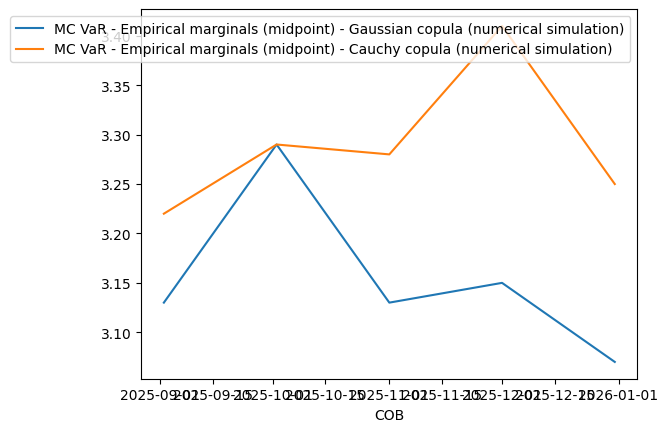

In [ ]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta

relpath = os.path.dirname(os.path.abspath(''))
ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\sp500.csv')
ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

cob_date_str='20251231'
market = mkt.Market(name='sp500', cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path='C:\\Temp')
market.load_history()

meth_list = [('GaussCopulaNum', 'MCVar'), ('CauchyCopulaNum', 'MCVar')]

res = pd.DataFrame(data=None, columns=range(len(meth_list)+1))
for i in range(5):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)
    date_res = [new_cob_date]
    col_res = ['COB']
    
    for meth in meth_list:
        copula = getattr(js, meth[0])
        joint_sim = copula(returns, [1.0]*len(ptf_names), seed=0)

        var_meth = getattr(v, meth[1])
        port_sim = var_meth(returns, market.spot, joint_sim, np.array(ptf_wghts), method='midpoint')
        port_sim.calculate_pnls(10000)
        port_var = round(port_sim.get_quantile(0.99)/port_sim.get_port_value()*100,2)
        date_res.append(port_var)
        col_res.append(port_sim.name)

    res.columns = col_res
    res_temp = pd.DataFrame(data=[date_res], columns=col_res)
    res = pd.concat([res, res_temp], ignore_index=True)

res.set_index('COB', inplace=True)
res = res.sort_index()
res.to_csv('C:\\Temp\\var.csv')
res.plot()
#todo 2) result stats i.e. multi quantile etc. 3) logging /storing with decorator 
